# Detecting Bangla DeepFake Audio: A Dual Approach Using LSTM and WaveNet

**Replication Study** — Based on the paper by Ayan et al. (2026)

This notebook replicates the methodology from the paper using our own Bangla audio dataset.
We implement two models:
1. **RNN-based LSTM** using MFCC features
2. **Custom WaveNet** using normalized raw audio waveforms

---

## 1. Imports and Configuration

In [1]:
import os
import glob
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------------
# NOTE: scikit-learn is intentionally NOT used.
# This keeps the notebook easy to run on Python 3.13 without compiling
# scikit-learn from source. We implement the few needed utilities here.
# ------------------------------------------------------------------

def stratified_split_indices(y, test_size=0.2, seed=42):
    """Return (train_idx, test_idx) with stratification by class."""
    y = np.asarray(y)
    rng = np.random.default_rng(seed)

    all_idx = np.arange(len(y))
    train_parts = []
    test_parts = []

    classes = np.unique(y)
    for cls in classes:
        cls_idx = all_idx[y == cls]
        rng.shuffle(cls_idx)

        if len(cls_idx) <= 1:
            n_test = 0
        else:
            n_test = int(round(len(cls_idx) * float(test_size)))
            n_test = max(1, min(len(cls_idx) - 1, n_test))

        test_parts.append(cls_idx[:n_test])
        train_parts.append(cls_idx[n_test:])

    test_idx = np.concatenate(test_parts) if len(test_parts) else np.array([], dtype=int)
    train_idx = np.concatenate(train_parts) if len(train_parts) else np.array([], dtype=int)

    rng.shuffle(test_idx)
    rng.shuffle(train_idx)
    return train_idx, test_idx


def confusion_matrix_np(y_true, y_pred, num_classes=2):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def _per_class_stats_from_cm(cm):
    tp = np.diag(cm).astype(np.float64)
    fp = cm.sum(axis=0).astype(np.float64) - tp
    fn = cm.sum(axis=1).astype(np.float64) - tp
    support = cm.sum(axis=1).astype(np.float64)

    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp), where=(tp + fp) != 0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp), where=(tp + fn) != 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp), where=(precision + recall) != 0)

    return precision, recall, f1, support


def accuracy_score_np(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(y_true == y_pred))


def weighted_precision_recall_f1_np(y_true, y_pred, num_classes=2):
    cm = confusion_matrix_np(y_true, y_pred, num_classes=num_classes)
    precision, recall, f1, support = _per_class_stats_from_cm(cm)
    total = support.sum() if support.sum() > 0 else 1.0
    w = support / total
    return float((precision * w).sum()), float((recall * w).sum()), float((f1 * w).sum())


def classification_report_np(y_true, y_pred, target_names=None, digits=4):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    num_classes = int(max(y_true.max(initial=0), y_pred.max(initial=0)) + 1)
    if target_names is None:
        target_names = [str(i) for i in range(num_classes)]

    cm = confusion_matrix_np(y_true, y_pred, num_classes=num_classes)
    precision, recall, f1, support = _per_class_stats_from_cm(cm)

    acc = accuracy_score_np(y_true, y_pred)
    w_prec, w_rec, w_f1 = weighted_precision_recall_f1_np(y_true, y_pred, num_classes=num_classes)

    fmt = f"{{:>{digits+6}.{digits}f}}"
    lines = []
    lines.append("".ljust(16) + "precision".rjust(12) + "recall".rjust(12) + "f1-score".rjust(12) + "support".rjust(12))

    for i, name in enumerate(target_names):
        lines.append(
            name.ljust(16)
            + fmt.format(precision[i]).rjust(12)
            + fmt.format(recall[i]).rjust(12)
            + fmt.format(f1[i]).rjust(12)
            + f"{int(support[i]):12d}"
        )

    lines.append("")
    lines.append("accuracy".ljust(16) + "".rjust(12) + "".rjust(12) + fmt.format(acc).rjust(12) + f"{int(support.sum()):12d}")
    lines.append("weighted avg".ljust(16) + fmt.format(w_prec).rjust(12) + fmt.format(w_rec).rjust(12) + fmt.format(w_f1).rjust(12) + f"{int(support.sum()):12d}")

    return "\n".join(lines)


def roc_curve_np(y_true, y_score):
    """Binary ROC curve (y_true in {0,1}). Returns (fpr, tpr, thresholds)."""
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=np.float64)

    order = np.argsort(-y_score, kind="mergesort")
    y_true = y_true[order]
    y_score = y_score[order]

    distinct = np.where(np.diff(y_score))[0]
    threshold_idxs = np.r_[distinct, y_true.size - 1]

    tps = np.cumsum(y_true)[threshold_idxs]
    fps = 1 + threshold_idxs - tps

    tps = np.r_[0, tps]
    fps = np.r_[0, fps]

    P = y_true.sum()
    N = y_true.size - P

    tpr = tps / P if P > 0 else np.zeros_like(tps, dtype=np.float64)
    fpr = fps / N if N > 0 else np.zeros_like(fps, dtype=np.float64)

    thresholds = np.r_[np.inf, y_score[threshold_idxs]]
    return fpr, tpr, thresholds


def auc_np(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    return float(np.trapz(y, x))


# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

Using device: cuda


In [2]:
# ============================================================
# Configuration — adjust paths and hyperparameters here
# ============================================================
BASE_DIR = r"./final_data"

# Dataset paths  (each source has real_wav/ and deepfake_wav/ subfolders)
DATASETS = {
    "mozilla": {
        "real": os.path.join(BASE_DIR, "deepfake_data_mozilla", "real_wav"),
        "fake": os.path.join(BASE_DIR, "deepfake_data_mozilla", "deepfake_wav"),
    },
    "sust": {
        "real": os.path.join(BASE_DIR, "deepfake_data_sust", "real_wav"),
        "fake": os.path.join(BASE_DIR, "deepfake_data_sust", "deepfake_wav"),
    },
}

# Audio processing
SAMPLE_RATE      = 16000   # Paper uses 16 kHz
AUDIO_DURATION   = 5       # seconds — pad/truncate to fixed length
N_MFCC           = 40      # Number of MFCC coefficients
MAX_LEN_MFCC     = 157     # Time frames for ~5 s at 16 kHz with default hop

# Training
TEST_SIZE        = 0.20
VAL_SIZE         = 0.10    # of the remaining training set
BATCH_SIZE       = 64      # For LSTM (MFCC features are small)
WAVENET_BATCH_SIZE = 16    # Smaller batch for WaveNet (raw audio is large)
LSTM_EPOCHS      = 40
WAVENET_EPOCHS   = 40
LSTM_LR          = 1e-4    # Paper: 0.0001
WAVENET_LR       = 1e-3    # Paper: 0.001
NUM_CLASSES      = 2

print("Configuration loaded.")

Configuration loaded.


## 2. Data Loading and Exploration

In [3]:
def collect_file_paths(datasets_dict):
    """Walk through dataset directories and collect (filepath, label) pairs."""
    records = []
    for source_name, paths in datasets_dict.items():
        for label_name, folder in paths.items():
            label = 0 if label_name == "real" else 1  # 0 = Real, 1 = Fake
            wav_files = glob.glob(os.path.join(folder, "*.wav"))
            for fp in wav_files:
                records.append({
                    "filepath": fp,
                    "label": label,
                    "label_name": label_name.capitalize(),
                    "source": source_name,
                })
    return pd.DataFrame(records)

df = collect_file_paths(DATASETS)
print(f"Total samples: {len(df)}")
print(f"\nLabel distribution:")
print(df['label_name'].value_counts())
print(f"\nSource distribution:")
print(df.groupby(['source', 'label_name']).size().unstack(fill_value=0))

Total samples: 25592

Label distribution:
label_name
Real    12796
Fake    12796
Name: count, dtype: int64

Source distribution:
label_name  Fake  Real
source                
mozilla     2797  2797
sust        9999  9999


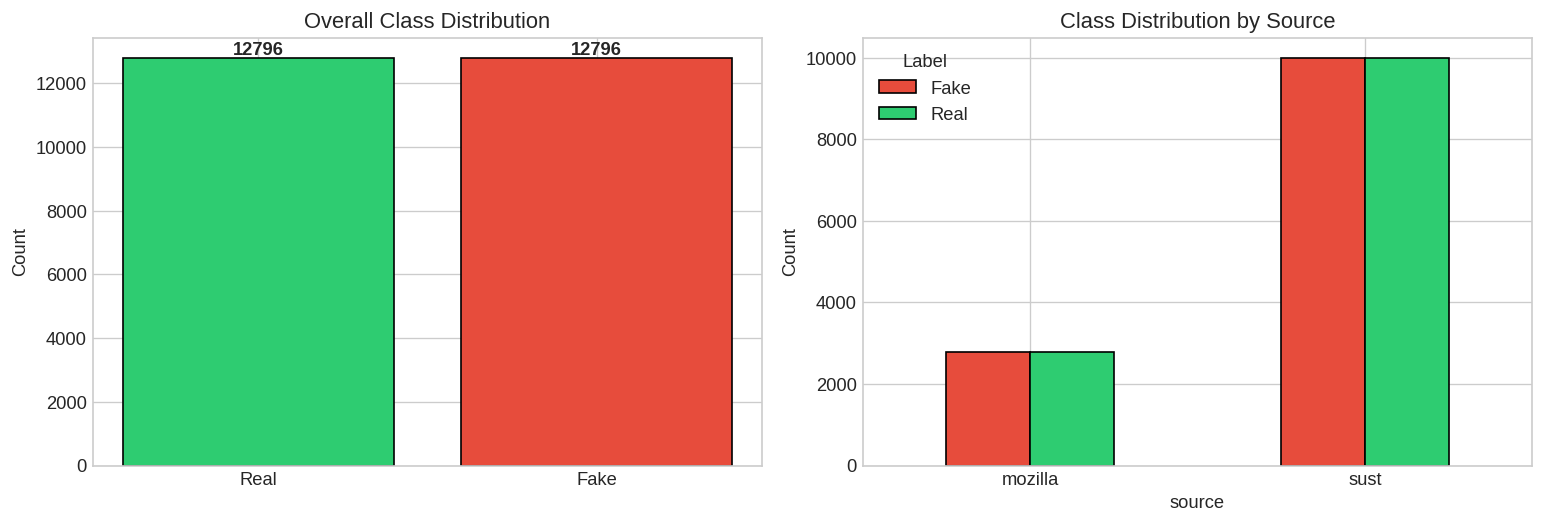

In [4]:
# --- Class distribution bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Overall distribution
counts = df['label_name'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Overall Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Per-source distribution
src_counts = df.groupby(['source', 'label_name']).size().unstack(fill_value=0)
src_counts.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('Class Distribution by Source')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Label')

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

## 3. Audio Visualization

In [5]:
def load_audio(filepath, sr=SAMPLE_RATE, duration=AUDIO_DURATION):
    """Load audio file, resample to target sr, pad/truncate to fixed duration."""
    y, sr_orig = librosa.load(filepath, sr=sr, duration=duration)
    target_len = sr * duration
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)), mode='constant')
    else:
        y = y[:target_len]
    return y, sr


# Pick one real and one fake sample for visualization
sample_real = df[df['label'] == 0].sample(1, random_state=SEED).iloc[0]
sample_fake = df[df['label'] == 1].sample(1, random_state=SEED).iloc[0]

y_real, _ = load_audio(sample_real['filepath'])
y_fake, _ = load_audio(sample_fake['filepath'])

print(f"Real sample: {os.path.basename(sample_real['filepath'])} (source: {sample_real['source']})")
print(f"Fake sample: {os.path.basename(sample_fake['filepath'])} (source: {sample_fake['source']})")

Real sample: 02119.wav (source: sust)
Fake sample: 9499.wav (source: sust)


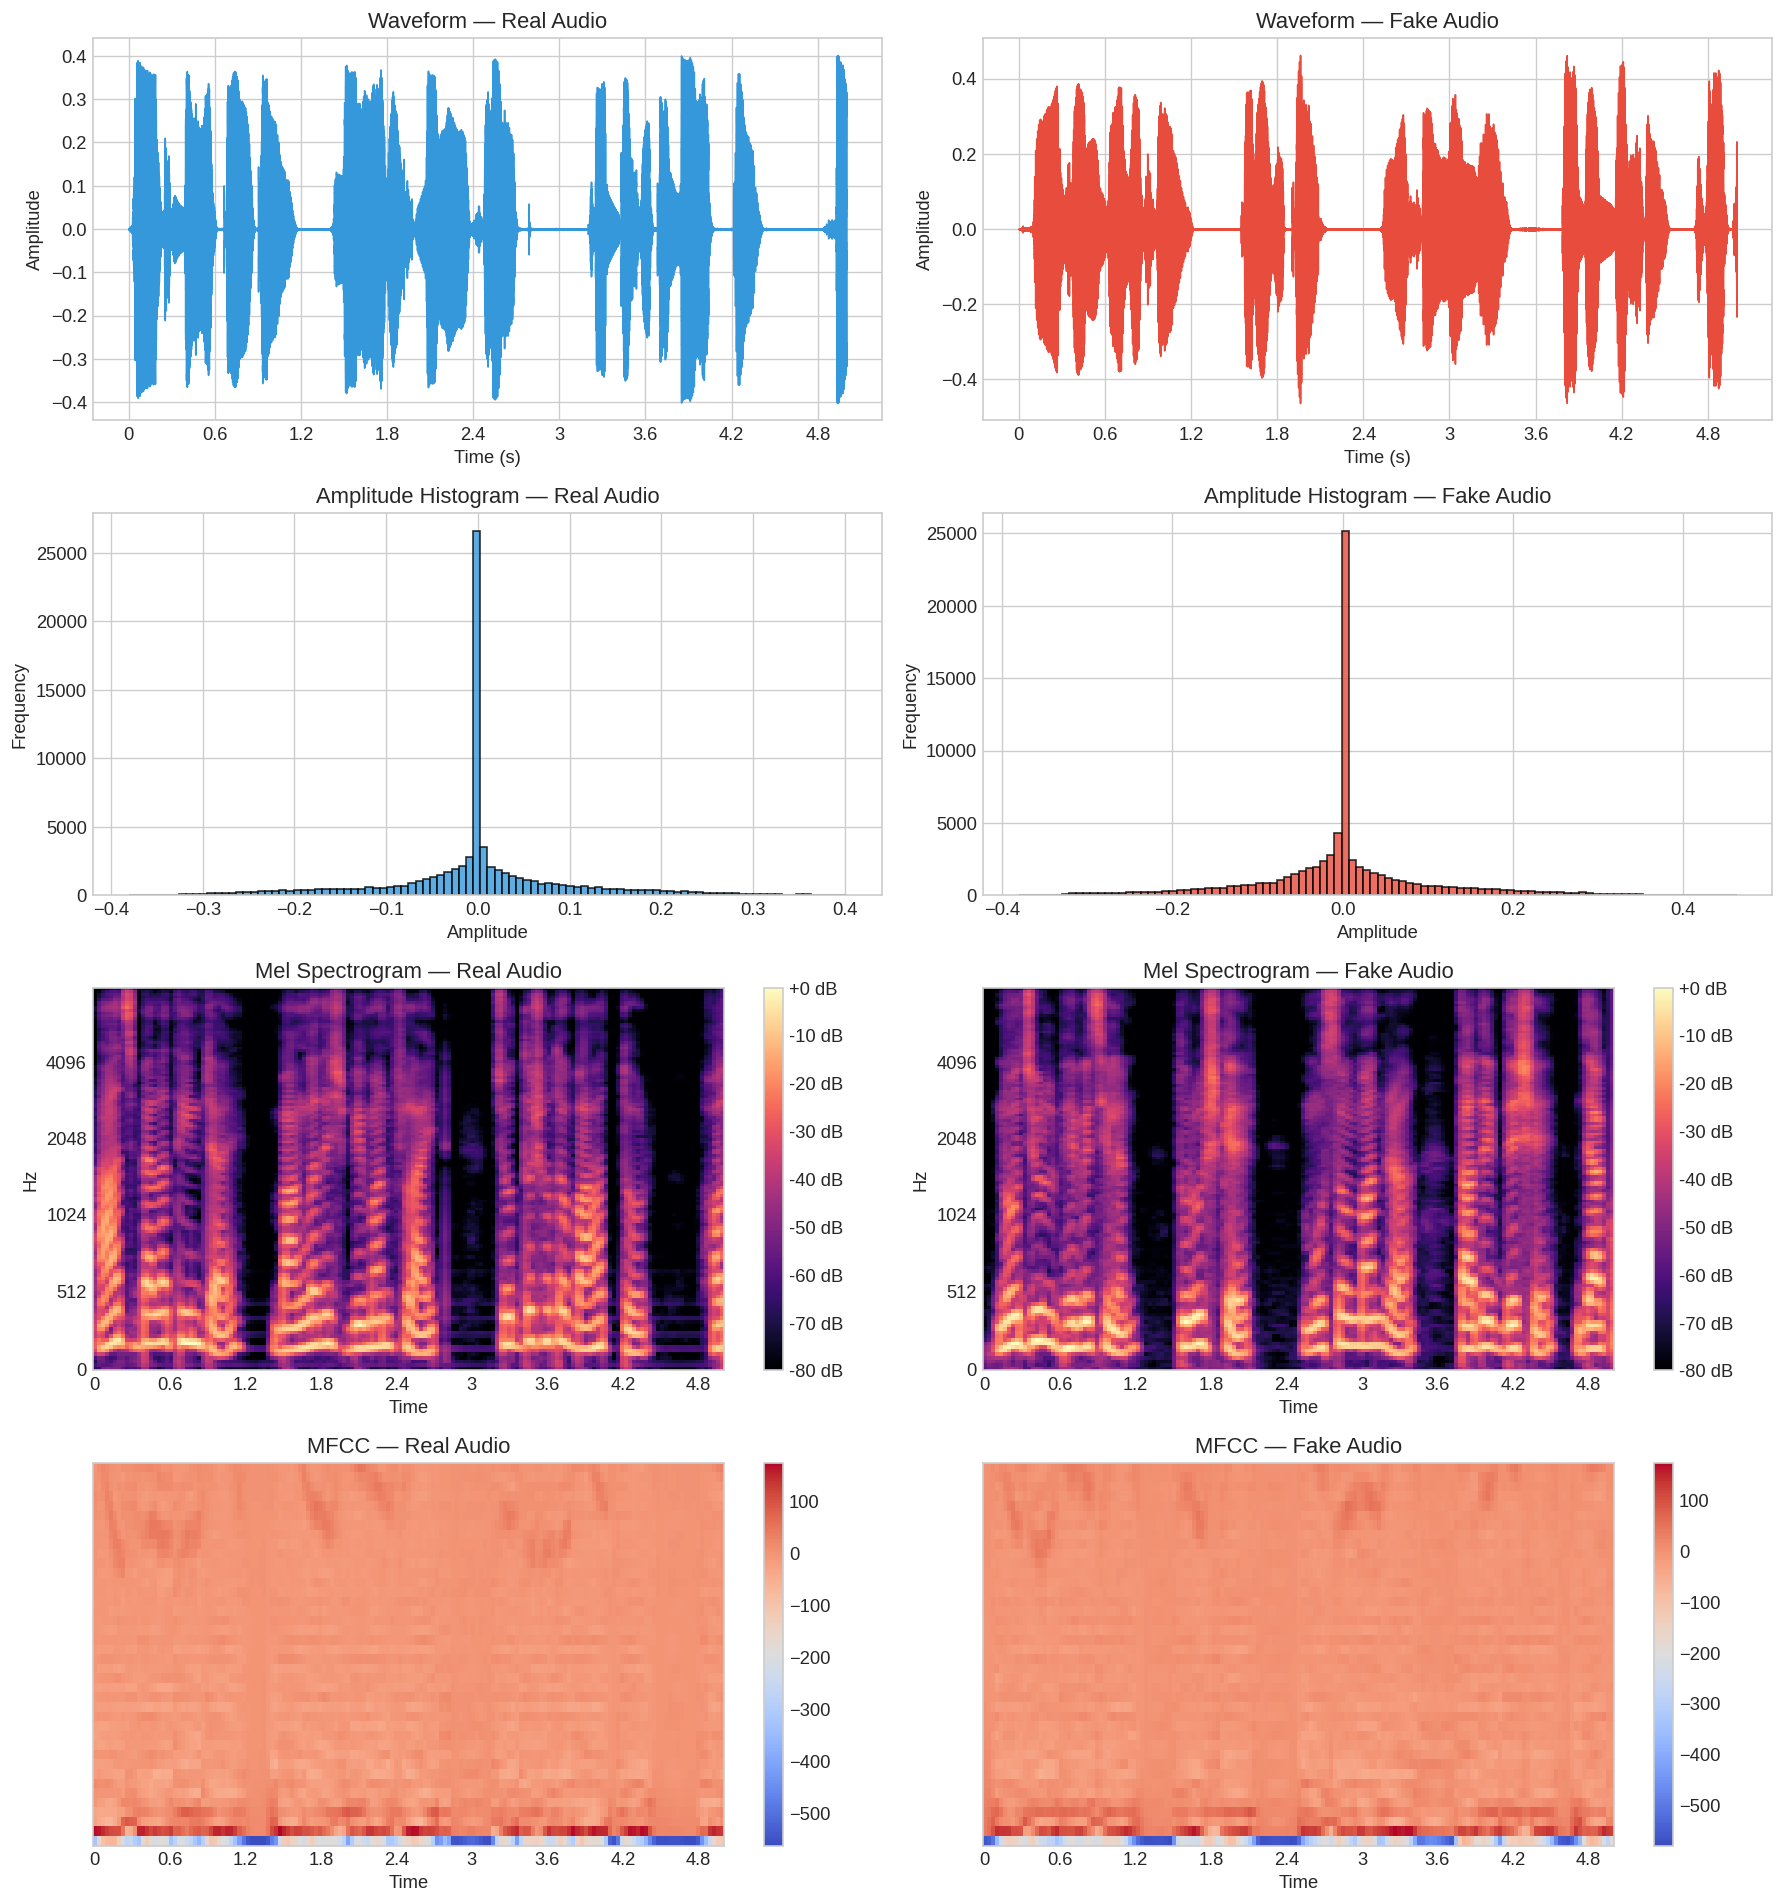

In [6]:
# --- Waveform, Histogram, Spectrogram, and MFCC for real vs. fake ---
fig, axes = plt.subplots(4, 2, figsize=(15, 16))

for col, (y, title) in enumerate([(y_real, 'Real Audio'), (y_fake, 'Fake Audio')]):
    # Waveform
    librosa.display.waveshow(y, sr=SAMPLE_RATE, ax=axes[0, col], color='#3498db' if col == 0 else '#e74c3c')
    axes[0, col].set_title(f'Waveform — {title}')
    axes[0, col].set_xlabel('Time (s)')
    axes[0, col].set_ylabel('Amplitude')

    # Histogram
    axes[1, col].hist(y, bins=100, color='#3498db' if col == 0 else '#e74c3c', alpha=0.8, edgecolor='black')
    axes[1, col].set_title(f'Amplitude Histogram — {title}')
    axes[1, col].set_xlabel('Amplitude')
    axes[1, col].set_ylabel('Frequency')

    # Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=SAMPLE_RATE, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, sr=SAMPLE_RATE, x_axis='time', y_axis='mel', ax=axes[2, col])
    axes[2, col].set_title(f'Mel Spectrogram — {title}')
    fig.colorbar(img, ax=axes[2, col], format='%+2.0f dB')

    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=SAMPLE_RATE, n_mfcc=N_MFCC)
    img2 = librosa.display.specshow(mfcc, sr=SAMPLE_RATE, x_axis='time', ax=axes[3, col])
    axes[3, col].set_title(f'MFCC — {title}')
    fig.colorbar(img2, ax=axes[3, col])

plt.tight_layout()
plt.savefig('audio_visualization.png', bbox_inches='tight')
plt.show()

In [7]:
# --- Listen to samples ---
print("Real Audio:")
ipd.display(ipd.Audio(y_real, rate=SAMPLE_RATE))
print("\nFake Audio:")
ipd.display(ipd.Audio(y_fake, rate=SAMPLE_RATE))

Real Audio:



Fake Audio:


## 4. Feature Extraction

### 4a. MFCC Features (for LSTM model)

As described in the paper, MFCC features are extracted from each audio file.
We extract **40 MFCC coefficients** per time frame and pad/truncate to a fixed number of time steps.

In [8]:
def extract_mfcc(filepath, sr=SAMPLE_RATE, duration=AUDIO_DURATION,
                 n_mfcc=N_MFCC, max_len=MAX_LEN_MFCC):
    """Extract MFCC features from an audio file."""
    y, _ = load_audio(filepath, sr=sr, duration=duration)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)  # (n_mfcc, time)
    # Pad or truncate time axis
    if mfcc.shape[1] < max_len:
        mfcc = np.pad(mfcc, ((0, 0), (0, max_len - mfcc.shape[1])), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    return mfcc.T  # (time, n_mfcc) — sequence-first for LSTM


def extract_raw_audio(filepath, sr=SAMPLE_RATE, duration=AUDIO_DURATION):
    """Load and normalize raw audio waveform (for WaveNet)."""
    y, _ = load_audio(filepath, sr=sr, duration=duration)
    # Normalize to [-1, 1]
    max_val = np.max(np.abs(y))
    if max_val > 0:
        y = y / max_val
    return y


# Quick test
test_mfcc = extract_mfcc(sample_real['filepath'])
test_raw = extract_raw_audio(sample_real['filepath'])
print(f"MFCC shape : {test_mfcc.shape}  — (time_steps, n_mfcc)")
print(f"Raw audio shape: {test_raw.shape} — (samples,)")

MFCC shape : (157, 40)  — (time_steps, n_mfcc)
Raw audio shape: (80000,) — (samples,)


In [9]:
# ============================================================
# Extract MFCC features for the full dataset
# Raw audio is loaded on-the-fly during training to save RAM
# (X_raw at float32 would be ~8 GB — enough to OOM-kill the kernel)
# ============================================================
print("Extracting MFCC features (raw audio will be loaded on-the-fly)...")

mfcc_features = []
labels = []
valid_indices = []
valid_filepaths = []   # keep paths for lazy raw-audio loading

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing audio"):
    try:
        mfcc = extract_mfcc(row['filepath'])
        # Validate that raw audio can also be loaded (fail fast)
        _ = load_audio(row['filepath'], sr=SAMPLE_RATE, duration=AUDIO_DURATION)
        mfcc_features.append(mfcc)
        labels.append(row['label'])
        valid_indices.append(idx)
        valid_filepaths.append(row['filepath'])
    except Exception as e:
        print(f"  Skipping {row['filepath']}: {e}")

X_mfcc = np.array(mfcc_features, dtype=np.float32)
del mfcc_features  # free the list immediately
y_all = np.array(labels, dtype=np.int64)
filepaths_all = np.array(valid_filepaths)

print(f"\nExtracted features for {len(y_all)} samples")
print(f"MFCC array shape : {X_mfcc.shape}")
print(f"Raw audio paths  : {len(filepaths_all)} (loaded on-the-fly during training)")
print(f"Label distribution: Real={np.sum(y_all == 0)}, Fake={np.sum(y_all == 1)}")

Extracting MFCC features (raw audio will be loaded on-the-fly)...


Processing audio:   0%|          | 0/25592 [00:00<?, ?it/s]

Processing audio: 100%|██████████| 25592/25592 [09:27<00:00, 45.13it/s]



Extracted features for 25592 samples
MFCC array shape : (25592, 157, 40)
Raw audio paths  : 25592 (loaded on-the-fly during training)
Label distribution: Real=12796, Fake=12796


## 5. Stratified Train / Validation / Test Split

Following the paper's methodology, we use stratified splitting to maintain class balance across sets.

In [10]:
# --- First split: train+val vs. test (80/20), stratified ---
train_val_idx, test_idx = stratified_split_indices(y_all, test_size=TEST_SIZE, seed=SEED)

# --- Second split: train vs. val from the train+val portion, stratified ---
relative_train_idx, relative_val_idx = stratified_split_indices(y_all[train_val_idx], test_size=VAL_SIZE, seed=SEED)
train_idx = train_val_idx[relative_train_idx]
val_idx = train_val_idx[relative_val_idx]

# MFCC splits (small enough to stay in RAM: ~600 MB)
X_train_mfcc, X_val_mfcc, X_test_mfcc = X_mfcc[train_idx], X_mfcc[val_idx], X_mfcc[test_idx]
y_train, y_val, y_test = y_all[train_idx], y_all[val_idx], y_all[test_idx]

# Free the unsplit array now that we have the splits
del X_mfcc
import gc; gc.collect()

# Raw audio: split file paths only (audio loaded on-the-fly in Dataset)
fp_train_raw = filepaths_all[train_idx]
fp_val_raw   = filepaths_all[val_idx]
fp_test_raw  = filepaths_all[test_idx]

print(f"Train : {len(y_train)} samples  (Real={np.sum(y_train==0)}, Fake={np.sum(y_train==1)})")
print(f"Val   : {len(y_val)} samples  (Real={np.sum(y_val==0)}, Fake={np.sum(y_val==1)})")
print(f"Test  : {len(y_test)} samples  (Real={np.sum(y_test==0)}, Fake={np.sum(y_test==1)})")

Train : 18426 samples  (Real=9213, Fake=9213)
Val   : 2048 samples  (Real=1024, Fake=1024)
Test  : 5118 samples  (Real=2559, Fake=2559)


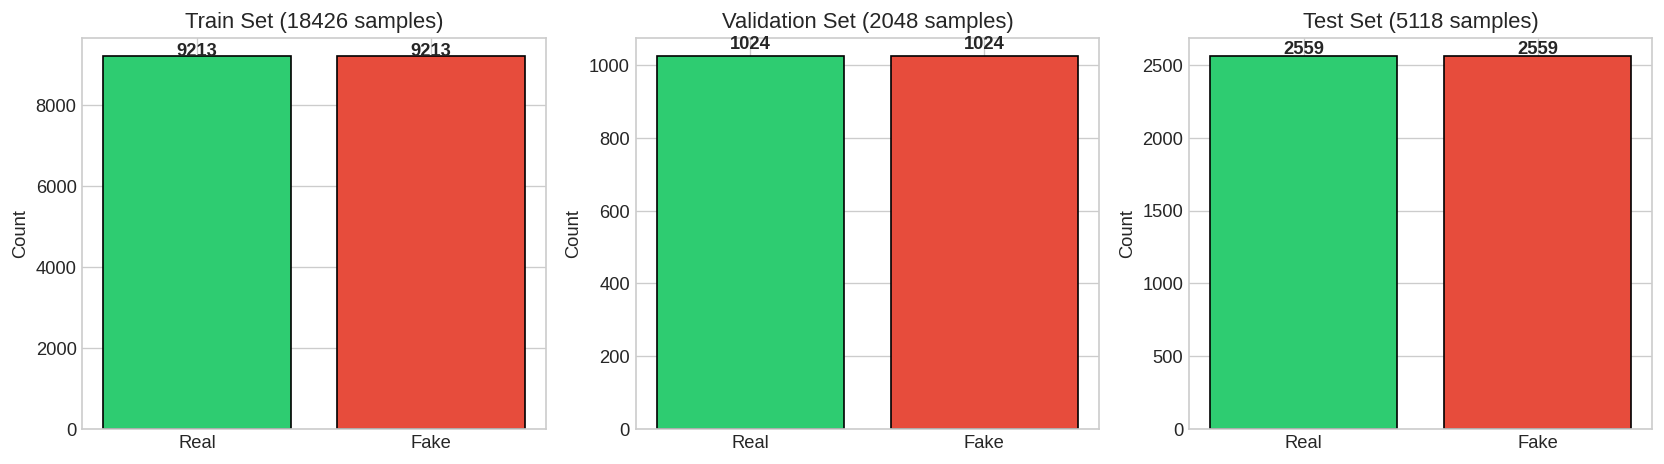

In [11]:
# --- Split distribution visualization ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (split_y, name) in zip(axes, [(y_train, 'Train'), (y_val, 'Validation'), (y_test, 'Test')]):
    unique, counts = np.unique(split_y, return_counts=True)
    label_names = ['Real', 'Fake']
    colors = ['#2ecc71', '#e74c3c']
    ax.bar(label_names, counts, color=colors, edgecolor='black')
    ax.set_title(f'{name} Set ({len(split_y)} samples)')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts):
        ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('split_distribution.png', bbox_inches='tight')
plt.show()

## 6. PyTorch Datasets and DataLoaders

In [12]:
class MFCCDataset(Dataset):
    """Dataset for MFCC features (LSTM model)."""
    def __init__(self, X, y):
        # Use from_numpy to share memory with the numpy array (no copy)
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class RawAudioDataset(Dataset):
    """
    Memory-efficient dataset for raw audio (WaveNet model).
    Loads audio from disk on-the-fly instead of holding everything in RAM.
    """
    def __init__(self, filepaths, y, sr=SAMPLE_RATE, duration=AUDIO_DURATION):
        self.filepaths = filepaths
        self.y = torch.from_numpy(y).long()
        self.sr = sr
        self.duration = duration

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        fp = self.filepaths[idx]
        raw = extract_raw_audio(fp, sr=self.sr, duration=self.duration)
        # WaveNet expects (channels, length) → unsqueeze channel dim
        x = torch.from_numpy(raw).float().unsqueeze(0)
        return x, self.y[idx]


# MFCC DataLoaders
train_mfcc_ds = MFCCDataset(X_train_mfcc, y_train)
val_mfcc_ds   = MFCCDataset(X_val_mfcc, y_val)
test_mfcc_ds  = MFCCDataset(X_test_mfcc, y_test)

train_mfcc_dl = DataLoader(train_mfcc_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_mfcc_dl   = DataLoader(val_mfcc_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_mfcc_dl  = DataLoader(test_mfcc_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# Raw Audio DataLoaders (lazy loading — no giant array in RAM)
train_raw_ds = RawAudioDataset(fp_train_raw, y_train)
val_raw_ds   = RawAudioDataset(fp_val_raw, y_val)
test_raw_ds  = RawAudioDataset(fp_test_raw, y_test)

train_raw_dl = DataLoader(train_raw_ds, batch_size=WAVENET_BATCH_SIZE, shuffle=True,  drop_last=False, num_workers=2, pin_memory=True)
val_raw_dl   = DataLoader(val_raw_ds,   batch_size=WAVENET_BATCH_SIZE, shuffle=False, drop_last=False, num_workers=2, pin_memory=True)
test_raw_dl  = DataLoader(test_raw_ds,  batch_size=WAVENET_BATCH_SIZE, shuffle=False, drop_last=False, num_workers=2, pin_memory=True)

print(f"MFCC     — Train batches: {len(train_mfcc_dl)}, Val: {len(val_mfcc_dl)}, Test: {len(test_mfcc_dl)}")
print(f"RawAudio — Train batches: {len(train_raw_dl)}, Val: {len(val_raw_dl)}, Test: {len(test_raw_dl)}")
print(f"  (Raw audio loaded on-the-fly, batch_size={WAVENET_BATCH_SIZE}, num_workers=2)")

MFCC     — Train batches: 288, Val: 32, Test: 80
RawAudio — Train batches: 1152, Val: 128, Test: 320
  (Raw audio loaded on-the-fly, batch_size=16, num_workers=2)


---
## 7. Model 1: RNN-Based LSTM

Following the paper:
- Input: MFCC features (time_steps, 40)
- LSTM layers with Tanh activation (built-in)
- Dropout rate = 0.5
- Dense layers with ReLU
- Output: Softmax over 2 classes
- Optimizer: Adam, lr = 0.0001

In [13]:
class LSTMModel(nn.Module):
    """
    RNN-based LSTM model for deepfake audio detection using MFCC features.
    Architecture follows the paper's description:
      - Bidirectional LSTM layers
      - Dropout (0.5)
      - Fully connected layers with ReLU
      - Softmax output
    """
    def __init__(self, input_size=N_MFCC, hidden_size=128, num_layers=2,
                 num_classes=NUM_CLASSES, dropout=0.5):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size * 2, 64)   # *2 for bidirectional
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # x: (batch, time_steps, n_mfcc)
        lstm_out, (h_n, c_n) = self.lstm(x)
        # Use the last time step output
        out = lstm_out[:, -1, :]  # (batch, hidden*2)
        out = self.dropout(out)
        out = self.relu(self.fc1(out))
        out = self.dropout(out)
        out = self.fc2(out)
        return out  # raw logits — use CrossEntropyLoss


lstm_model = LSTMModel().to(DEVICE)
print(lstm_model)
total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

LSTMModel(
  (lstm): LSTM(40, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

Total trainable parameters: 585,922


### 7a. LSTM Training Loop

In [14]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        running_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [15]:
# --- Train LSTM ---
lstm_criterion = nn.CrossEntropyLoss()
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=LSTM_LR)
lstm_scheduler = optim.lr_scheduler.ReduceLROnPlateau(lstm_optimizer, mode='min', patience=5, factor=0.5)

lstm_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc_lstm = 0.0

print("Training LSTM Model...")
print("=" * 70)

for epoch in range(1, LSTM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(lstm_model, train_mfcc_dl, lstm_criterion, lstm_optimizer, DEVICE)
    val_loss, val_acc = evaluate(lstm_model, val_mfcc_dl, lstm_criterion, DEVICE)
    lstm_scheduler.step(val_loss)

    lstm_history['train_loss'].append(train_loss)
    lstm_history['train_acc'].append(train_acc)
    lstm_history['val_loss'].append(val_loss)
    lstm_history['val_acc'].append(val_acc)

    # Save best model
    if val_acc > best_val_acc_lstm:
        best_val_acc_lstm = val_acc
        torch.save(lstm_model.state_dict(), 'best_lstm_model.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{LSTM_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

print("=" * 70)
print(f"Best Validation Accuracy: {best_val_acc_lstm:.4f}")

Training LSTM Model...
Epoch   1/40 | Train Loss: 0.6861 Acc: 0.5453 | Val Loss: 0.6389 Acc: 0.6685
Epoch   5/40 | Train Loss: 0.6586 Acc: 0.6152 | Val Loss: 0.6008 Acc: 0.7017
Epoch  10/40 | Train Loss: 0.1719 Acc: 0.9505 | Val Loss: 0.2085 Acc: 0.9023
Epoch  15/40 | Train Loss: 0.0759 Acc: 0.9766 | Val Loss: 0.0911 Acc: 0.9780
Epoch  20/40 | Train Loss: 0.0480 Acc: 0.9878 | Val Loss: 0.0252 Acc: 0.9927
Epoch  25/40 | Train Loss: 0.0448 Acc: 0.9887 | Val Loss: 0.0408 Acc: 0.9893
Epoch  30/40 | Train Loss: 0.0584 Acc: 0.9840 | Val Loss: 0.0489 Acc: 0.9849
Epoch  35/40 | Train Loss: 0.0286 Acc: 0.9918 | Val Loss: 0.0455 Acc: 0.9907
Epoch  40/40 | Train Loss: 0.0223 Acc: 0.9929 | Val Loss: 0.0419 Acc: 0.9912
Best Validation Accuracy: 0.9927


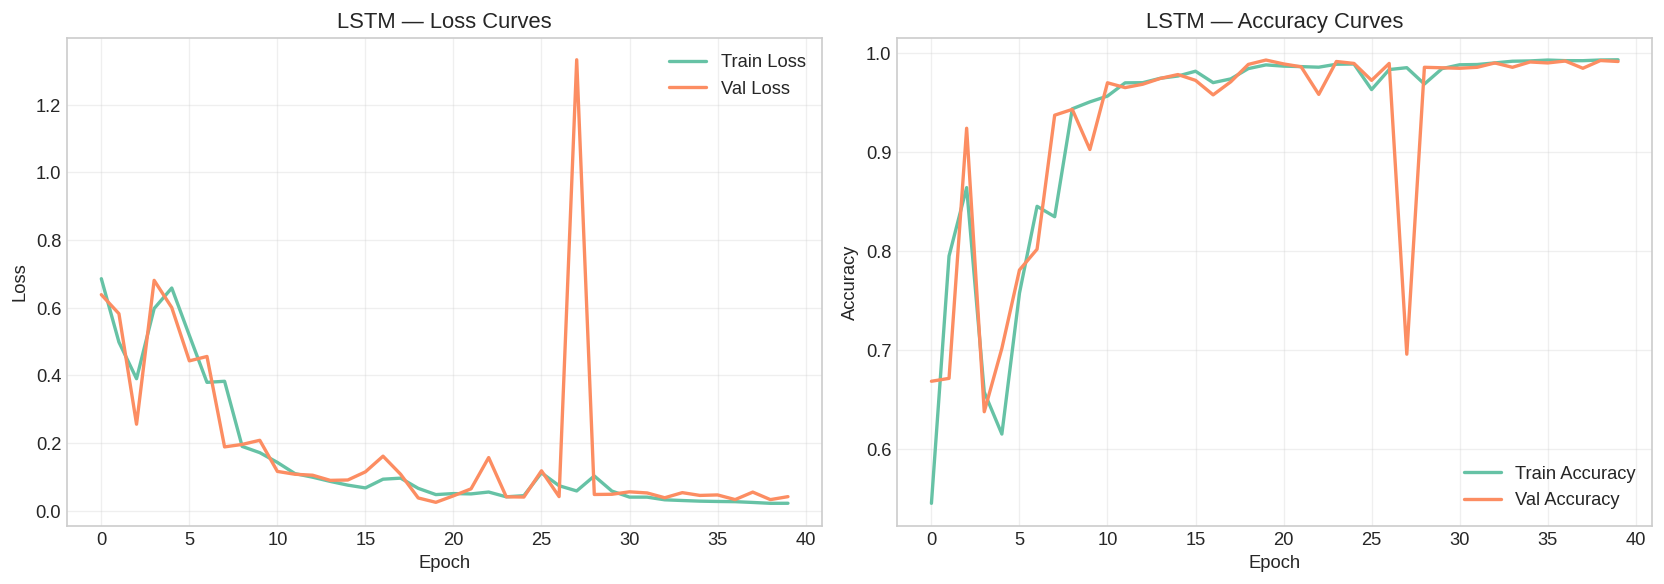

In [16]:
# --- LSTM Training Curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(lstm_history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(lstm_history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_title('LSTM — Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(lstm_history['train_acc'], label='Train Accuracy', linewidth=2)
ax2.plot(lstm_history['val_acc'], label='Val Accuracy', linewidth=2)
ax2.set_title('LSTM — Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_curves.png', bbox_inches='tight')
plt.show()

### 7b. LSTM Evaluation on Test Set

In [17]:
@torch.no_grad()
def get_predictions(model, dataloader, device):
    """Get all predictions and true labels from a dataloader."""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [18]:
# Load best LSTM model
lstm_model.load_state_dict(torch.load('best_lstm_model.pth', map_location=DEVICE, weights_only=True))

y_true_lstm, y_pred_lstm, y_prob_lstm = get_predictions(lstm_model, test_mfcc_dl, DEVICE)

print("=" * 60)
print("LSTM Model - Test Set Classification Report")
print("=" * 60)
print(classification_report_np(y_true_lstm, y_pred_lstm, target_names=['Real', 'Fake'], digits=4))

lstm_test_acc = accuracy_score_np(y_true_lstm, y_pred_lstm)
lstm_test_prec, lstm_test_rec, lstm_test_f1 = weighted_precision_recall_f1_np(y_true_lstm, y_pred_lstm, num_classes=2)

print(f"Overall Accuracy : {lstm_test_acc:.4f}")
print(f"Weighted Precision: {lstm_test_prec:.4f}")
print(f"Weighted Recall   : {lstm_test_rec:.4f}")
print(f"Weighted F1 Score : {lstm_test_f1:.4f}")

LSTM Model - Test Set Classification Report
                   precision      recall    f1-score     support
Real                  0.9929      0.9809      0.9868        2559
Fake                  0.9811      0.9930      0.9870        2559

accuracy                                      0.9869        5118
weighted avg          0.9870      0.9869      0.9869        5118
Overall Accuracy : 0.9869
Weighted Precision: 0.9870
Weighted Recall   : 0.9869
Weighted F1 Score : 0.9869


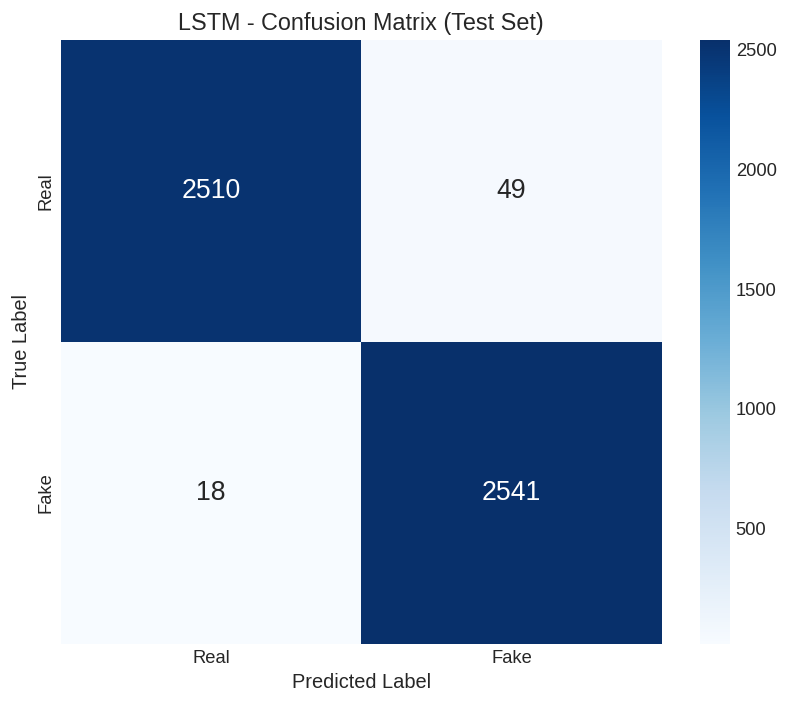

In [19]:
# --- LSTM Confusion Matrix ---
cm_lstm = confusion_matrix_np(y_true_lstm, y_pred_lstm, num_classes=2)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
            annot_kws={'size': 16}, ax=ax)
ax.set_title('LSTM - Confusion Matrix (Test Set)', fontsize=14)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', bbox_inches='tight')
plt.show()

---
## 8. Model 2: WaveNet

Following the paper:
- Input: Normalized raw audio waveforms
- Dilated causal convolutions with exponentially growing dilation factors
- Residual and skip connections
- Optimizer: Adam, lr = 0.001
- No explicit dropout (regularization via residual/skip connections)

In [20]:
class CausalConv1d(nn.Module):
    """Causal convolution: output at time t depends only on inputs at time <= t."""
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super(CausalConv1d, self).__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,
                              dilation=dilation, padding=self.padding)

    def forward(self, x):
        out = self.conv(x)
        # Remove future timesteps (causal)
        if self.padding > 0:
            out = out[:, :, :-self.padding]
        return out


class WaveNetResidualBlock(nn.Module):
    """Single WaveNet residual block with dilated causal convolution."""
    def __init__(self, residual_channels, skip_channels, kernel_size, dilation):
        super(WaveNetResidualBlock, self).__init__()
        self.dilated_conv = CausalConv1d(
            residual_channels, 2 * residual_channels, kernel_size, dilation
        )
        self.residual_conv = nn.Conv1d(residual_channels, residual_channels, 1)
        self.skip_conv = nn.Conv1d(residual_channels, skip_channels, 1)

    def forward(self, x):
        out = self.dilated_conv(x)
        # Gated activation (tanh * sigmoid)
        tanh_out = torch.tanh(out[:, :out.size(1)//2, :])
        sig_out = torch.sigmoid(out[:, out.size(1)//2:, :])
        gated = tanh_out * sig_out

        # Skip connection
        skip = self.skip_conv(gated)

        # Residual connection
        residual = self.residual_conv(gated) + x

        return residual, skip


class WaveNetClassifier(nn.Module):
    """
    WaveNet-based classifier for deepfake audio detection.
    Uses dilated causal convolutions with residual + skip connections.
    """
    def __init__(self, in_channels=1, residual_channels=32, skip_channels=32,
                 kernel_size=2, num_blocks=10, num_classes=NUM_CLASSES):
        super(WaveNetClassifier, self).__init__()

        # Initial causal convolution
        self.input_conv = CausalConv1d(in_channels, residual_channels, kernel_size=1)

        # Stack of residual blocks with exponentially growing dilation
        self.residual_blocks = nn.ModuleList()
        for i in range(num_blocks):
            dilation = 2 ** i
            self.residual_blocks.append(
                WaveNetResidualBlock(residual_channels, skip_channels, kernel_size, dilation)
            )

        # Output layers
        self.output_conv1 = nn.Conv1d(skip_channels, skip_channels, 1)
        self.output_conv2 = nn.Conv1d(skip_channels, num_classes, 1)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        # x: (batch, 1, length)
        x = self.input_conv(x)

        skip_sum = 0
        for block in self.residual_blocks:
            x, skip = block(x)
            skip_sum = skip_sum + skip

        # Post-processing
        out = F.relu(skip_sum)
        out = F.relu(self.output_conv1(out))
        out = self.output_conv2(out)

        # Global average pooling -> (batch, num_classes)
        out = self.global_pool(out).squeeze(-1)
        return out


wavenet_model = WaveNetClassifier().to(DEVICE)
print(wavenet_model)
total_params_wn = sum(p.numel() for p in wavenet_model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params_wn:,}")

WaveNetClassifier(
  (input_conv): CausalConv1d(
    (conv): Conv1d(1, 32, kernel_size=(1,), stride=(1,))
  )
  (residual_blocks): ModuleList(
    (0): WaveNetResidualBlock(
      (dilated_conv): CausalConv1d(
        (conv): Conv1d(32, 64, kernel_size=(2,), stride=(1,), padding=(1,))
      )
      (residual_conv): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
      (skip_conv): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
    )
    (1): WaveNetResidualBlock(
      (dilated_conv): CausalConv1d(
        (conv): Conv1d(32, 64, kernel_size=(2,), stride=(1,), padding=(2,), dilation=(2,))
      )
      (residual_conv): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
      (skip_conv): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
    )
    (2): WaveNetResidualBlock(
      (dilated_conv): CausalConv1d(
        (conv): Conv1d(32, 64, kernel_size=(2,), stride=(1,), padding=(4,), dilation=(4,))
      )
      (residual_conv): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
      (skip_conv): Conv1d

### 8a. WaveNet Training Loop

In [21]:
# --- Train WaveNet ---
wavenet_criterion = nn.CrossEntropyLoss()
wavenet_optimizer = optim.Adam(wavenet_model.parameters(), lr=WAVENET_LR)
wavenet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(wavenet_optimizer, mode='min', patience=5, factor=0.5)

wavenet_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc_wn = 0.0

print("Training WaveNet Model...")
print("=" * 70)

for epoch in range(1, WAVENET_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(wavenet_model, train_raw_dl, wavenet_criterion, wavenet_optimizer, DEVICE)
    val_loss, val_acc = evaluate(wavenet_model, val_raw_dl, wavenet_criterion, DEVICE)
    wavenet_scheduler.step(val_loss)

    wavenet_history['train_loss'].append(train_loss)
    wavenet_history['train_acc'].append(train_acc)
    wavenet_history['val_loss'].append(val_loss)
    wavenet_history['val_acc'].append(val_acc)

    # Save best model
    if val_acc > best_val_acc_wn:
        best_val_acc_wn = val_acc
        torch.save(wavenet_model.state_dict(), 'best_wavenet_model.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{WAVENET_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

print("=" * 70)
print(f"Best Validation Accuracy: {best_val_acc_wn:.4f}")

Training WaveNet Model...
Epoch   1/40 | Train Loss: 0.6904 Acc: 0.5153 | Val Loss: 0.6933 Acc: 0.5000
Epoch   5/40 | Train Loss: 0.6933 Acc: 0.4995 | Val Loss: 0.6933 Acc: 0.5000
Epoch  10/40 | Train Loss: 0.6932 Acc: 0.5027 | Val Loss: 0.6932 Acc: 0.5000
Epoch  15/40 | Train Loss: 0.6932 Acc: 0.4919 | Val Loss: 0.6932 Acc: 0.5000
Epoch  20/40 | Train Loss: 0.6932 Acc: 0.5001 | Val Loss: 0.6931 Acc: 0.5000
Epoch  25/40 | Train Loss: 0.6932 Acc: 0.4969 | Val Loss: 0.6931 Acc: 0.5000
Epoch  30/40 | Train Loss: 0.6932 Acc: 0.4978 | Val Loss: 0.6931 Acc: 0.5000
Epoch  35/40 | Train Loss: 0.6932 Acc: 0.4987 | Val Loss: 0.6931 Acc: 0.5000
Epoch  40/40 | Train Loss: 0.6931 Acc: 0.4923 | Val Loss: 0.6931 Acc: 0.5000
Best Validation Accuracy: 0.5000


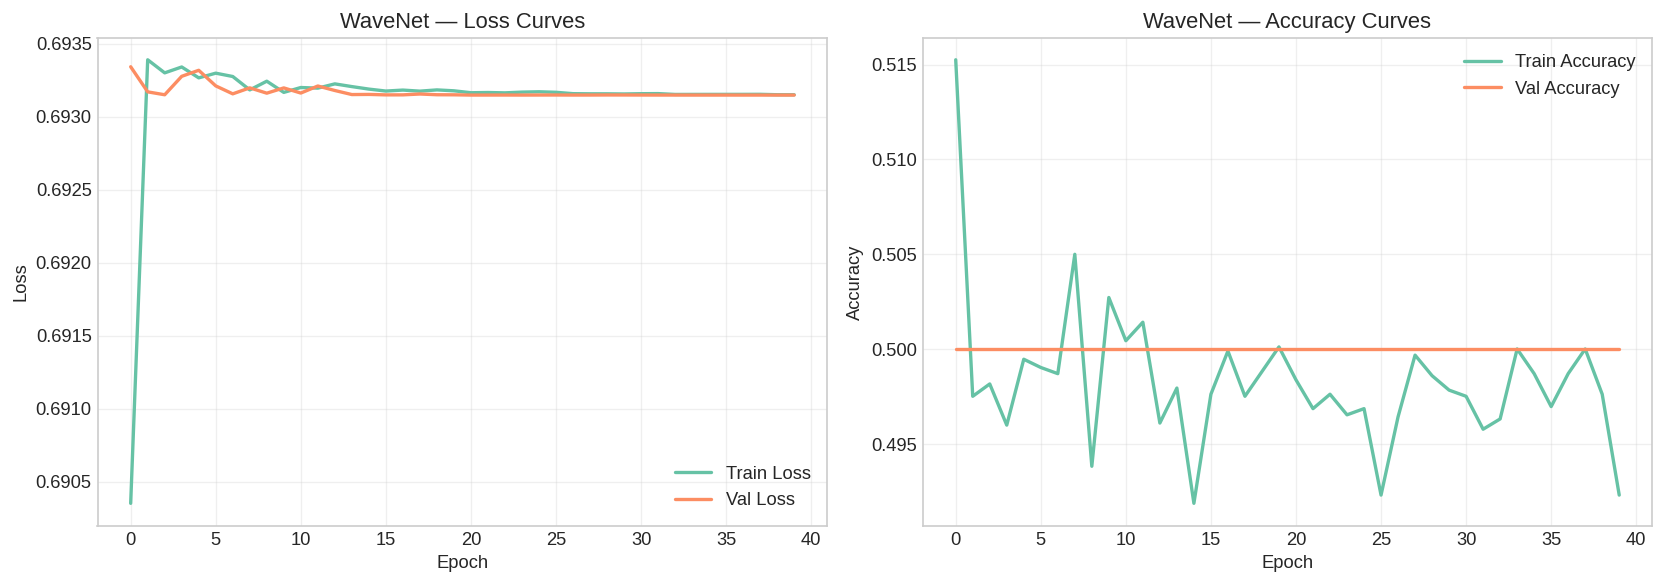

In [22]:
# --- WaveNet Training Curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(wavenet_history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(wavenet_history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_title('WaveNet — Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(wavenet_history['train_acc'], label='Train Accuracy', linewidth=2)
ax2.plot(wavenet_history['val_acc'], label='Val Accuracy', linewidth=2)
ax2.set_title('WaveNet — Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('wavenet_training_curves.png', bbox_inches='tight')
plt.show()

### 8b. WaveNet Evaluation on Test Set

In [23]:
# Load best WaveNet model
wavenet_model.load_state_dict(torch.load('best_wavenet_model.pth', map_location=DEVICE, weights_only=True))

y_true_wn, y_pred_wn, y_prob_wn = get_predictions(wavenet_model, test_raw_dl, DEVICE)

print("=" * 60)
print("WaveNet Model - Test Set Classification Report")
print("=" * 60)
print(classification_report_np(y_true_wn, y_pred_wn, target_names=['Real', 'Fake'], digits=4))

wn_test_acc = accuracy_score_np(y_true_wn, y_pred_wn)
wn_test_prec, wn_test_rec, wn_test_f1 = weighted_precision_recall_f1_np(y_true_wn, y_pred_wn, num_classes=2)

print(f"Overall Accuracy : {wn_test_acc:.4f}")
print(f"Weighted Precision: {wn_test_prec:.4f}")
print(f"Weighted Recall   : {wn_test_rec:.4f}")
print(f"Weighted F1 Score : {wn_test_f1:.4f}")

WaveNet Model - Test Set Classification Report
                   precision      recall    f1-score     support
Real                  0.5000      1.0000      0.6667        2559
Fake                  0.0000      0.0000      0.0000        2559

accuracy                                      0.5000        5118
weighted avg          0.2500      0.5000      0.3333        5118
Overall Accuracy : 0.5000
Weighted Precision: 0.2500
Weighted Recall   : 0.5000
Weighted F1 Score : 0.3333


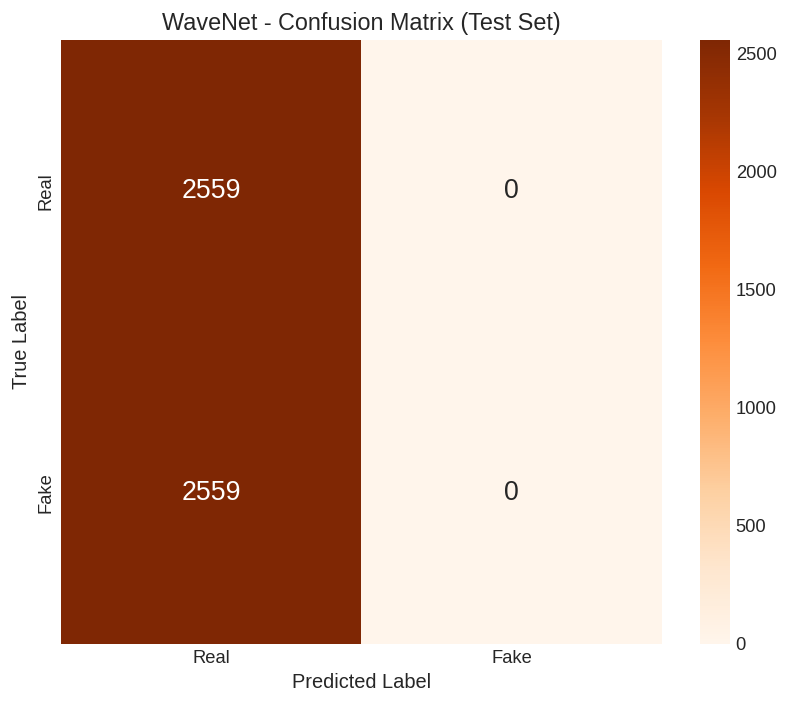

In [24]:
# --- WaveNet Confusion Matrix ---
cm_wn = confusion_matrix_np(y_true_wn, y_pred_wn, num_classes=2)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_wn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
            annot_kws={'size': 16}, ax=ax)
ax.set_title('WaveNet - Confusion Matrix (Test Set)', fontsize=14)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('wavenet_confusion_matrix.png', bbox_inches='tight')
plt.show()

---
## 9. Comparison of Results

We now compare both models against each other and against the paper's reported results:
- **Paper LSTM**: 89% accuracy
- **Paper WaveNet**: 91% accuracy

In [25]:
# --- Results Comparison Table ---
results_df = pd.DataFrame({
    'Model': ['LSTM (Paper)', 'WaveNet (Paper)', 'LSTM (Ours)', 'WaveNet (Ours)'],
    'Accuracy': [0.89, 0.91, lstm_test_acc, wn_test_acc],
    'Precision': [0.8906, 0.91, lstm_test_prec, wn_test_prec],
    'Recall': [0.8898, 0.91, lstm_test_rec, wn_test_rec],
    'F1 Score': [0.8967, 0.91, lstm_test_f1, wn_test_f1],
})

print("\n" + "=" * 75)
print("COMPARISON: Paper Results vs Our Results")
print("=" * 75)
print(results_df.to_string(index=False, float_format='%.4f'))
print("=" * 75)


COMPARISON: Paper Results vs Our Results
          Model  Accuracy  Precision  Recall  F1 Score
   LSTM (Paper)    0.8900     0.8906  0.8898    0.8967
WaveNet (Paper)    0.9100     0.9100  0.9100    0.9100
    LSTM (Ours)    0.9869     0.9870  0.9869    0.9869
 WaveNet (Ours)    0.5000     0.2500  0.5000    0.3333


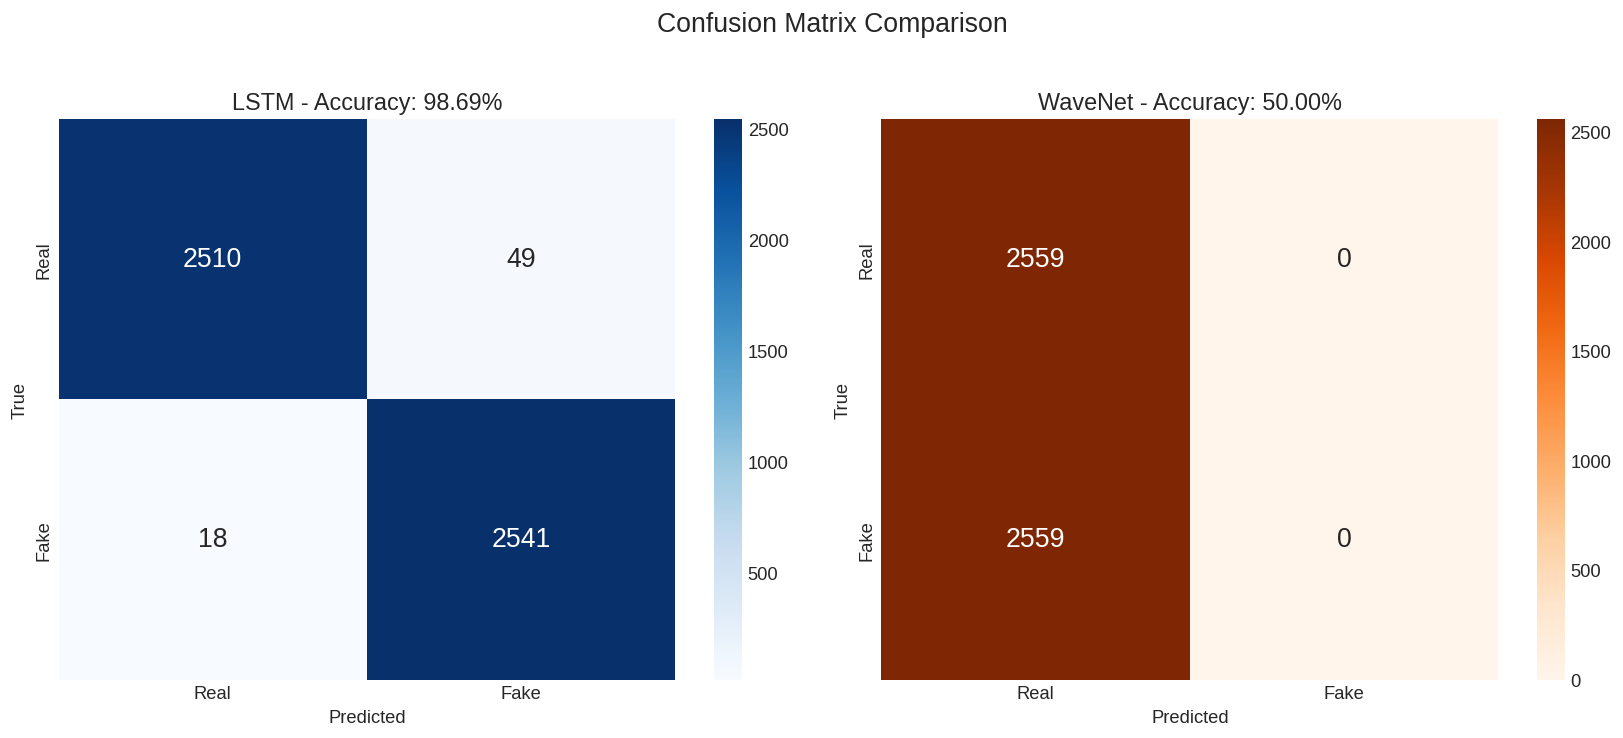

In [26]:
# --- Side-by-side Confusion Matrices ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
            annot_kws={'size': 16}, ax=ax1)
ax1.set_title(f'LSTM - Accuracy: {lstm_test_acc:.2%}', fontsize=14)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')

sns.heatmap(cm_wn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
            annot_kws={'size': 16}, ax=ax2)
ax2.set_title(f'WaveNet - Accuracy: {wn_test_acc:.2%}', fontsize=14)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')

plt.suptitle('Confusion Matrix Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', bbox_inches='tight')
plt.show()

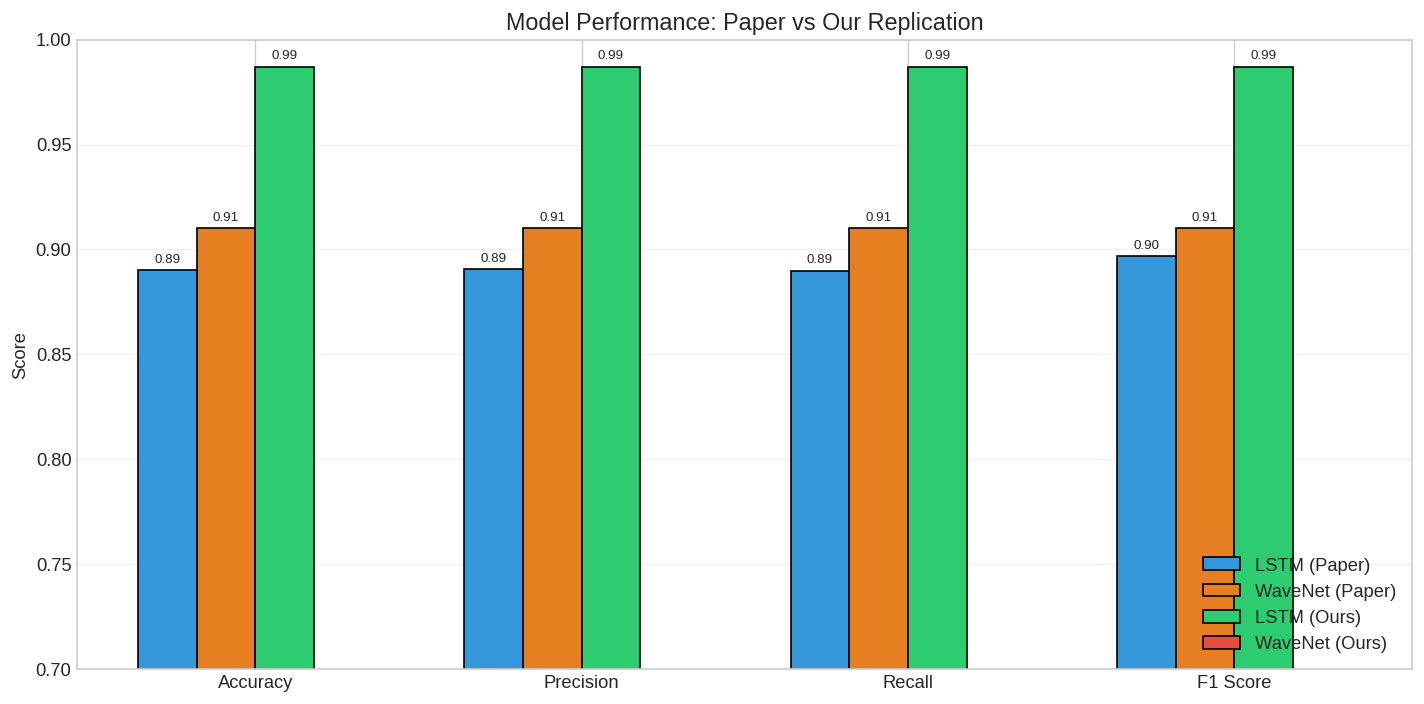

In [27]:
# --- Grouped Bar Chart: Paper vs Ours ---
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.18

paper_lstm = [0.89, 0.8906, 0.8898, 0.8967]
paper_wn   = [0.91, 0.91,   0.91,   0.91]
our_lstm   = [lstm_test_acc, lstm_test_prec, lstm_test_rec, lstm_test_f1]
our_wn     = [wn_test_acc,   wn_test_prec,   wn_test_rec,   wn_test_f1]

bars1 = ax.bar(x - 1.5*width, paper_lstm, width, label='LSTM (Paper)', color='#3498db', edgecolor='black')
bars2 = ax.bar(x - 0.5*width, paper_wn,   width, label='WaveNet (Paper)', color='#e67e22', edgecolor='black')
bars3 = ax.bar(x + 0.5*width, our_lstm,   width, label='LSTM (Ours)', color='#2ecc71', edgecolor='black')
bars4 = ax.bar(x + 1.5*width, our_wn,     width, label='WaveNet (Ours)', color='#e74c3c', edgecolor='black')

ax.set_ylabel('Score')
ax.set_title('Model Performance: Paper vs Our Replication', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0.7, 1.0)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('results_comparison.png', bbox_inches='tight')
plt.show()

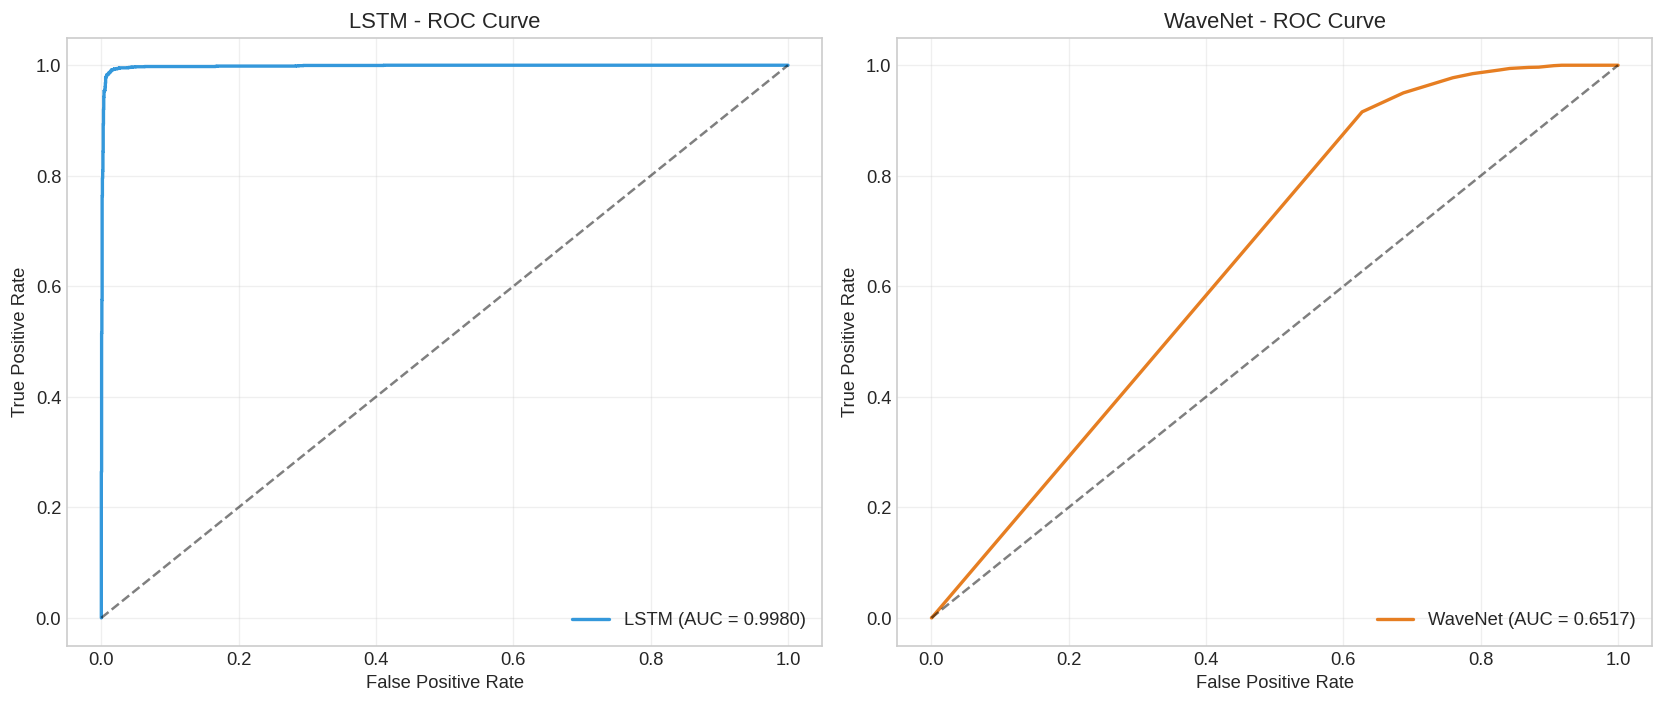

In [28]:
# --- ROC Curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# LSTM ROC
fpr_lstm, tpr_lstm, _ = roc_curve_np(y_true_lstm, y_prob_lstm[:, 1])
roc_auc_lstm = auc_np(fpr_lstm, tpr_lstm)
ax1.plot(fpr_lstm, tpr_lstm, color='#3498db', linewidth=2, label=f'LSTM (AUC = {roc_auc_lstm:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('LSTM - ROC Curve')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# WaveNet ROC
fpr_wn, tpr_wn, _ = roc_curve_np(y_true_wn, y_prob_wn[:, 1])
roc_auc_wn = auc_np(fpr_wn, tpr_wn)
ax2.plot(fpr_wn, tpr_wn, color='#e67e22', linewidth=2, label=f'WaveNet (AUC = {roc_auc_wn:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('WaveNet - ROC Curve')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

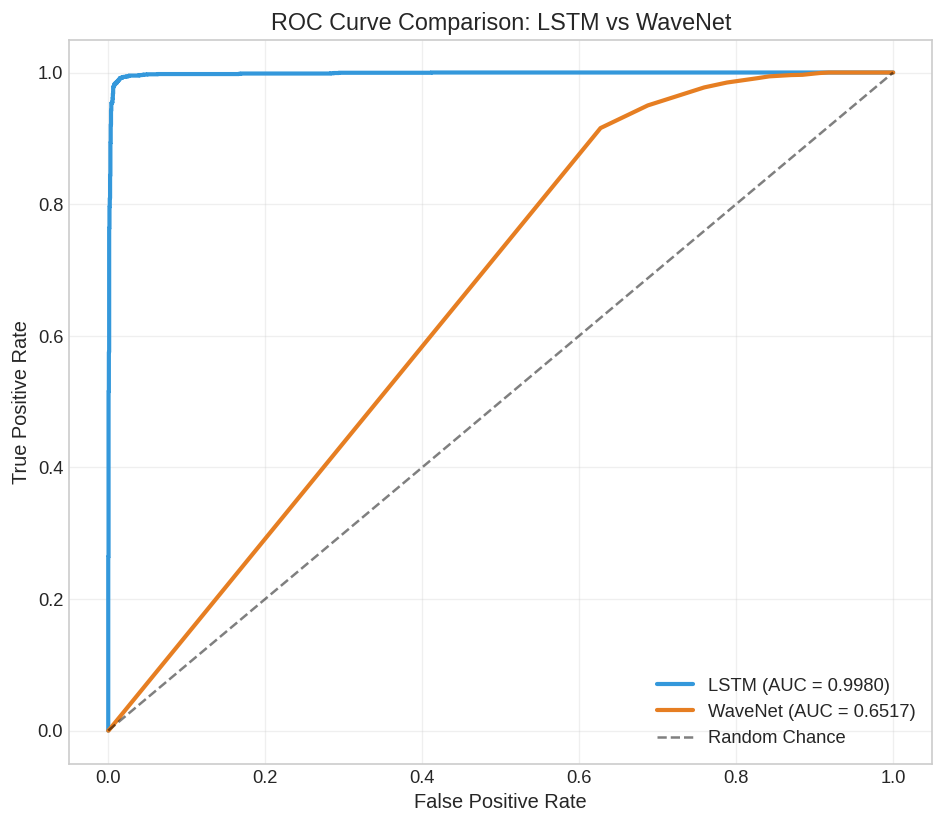

In [29]:
# --- Combined ROC on a single plot ---
fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(fpr_lstm, tpr_lstm, color='#3498db', linewidth=2.5,
        label=f'LSTM (AUC = {roc_auc_lstm:.4f})')
ax.plot(fpr_wn, tpr_wn, color='#e67e22', linewidth=2.5,
        label=f'WaveNet (AUC = {roc_auc_wn:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Chance')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison: LSTM vs WaveNet', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_comparison.png', bbox_inches='tight')
plt.show()

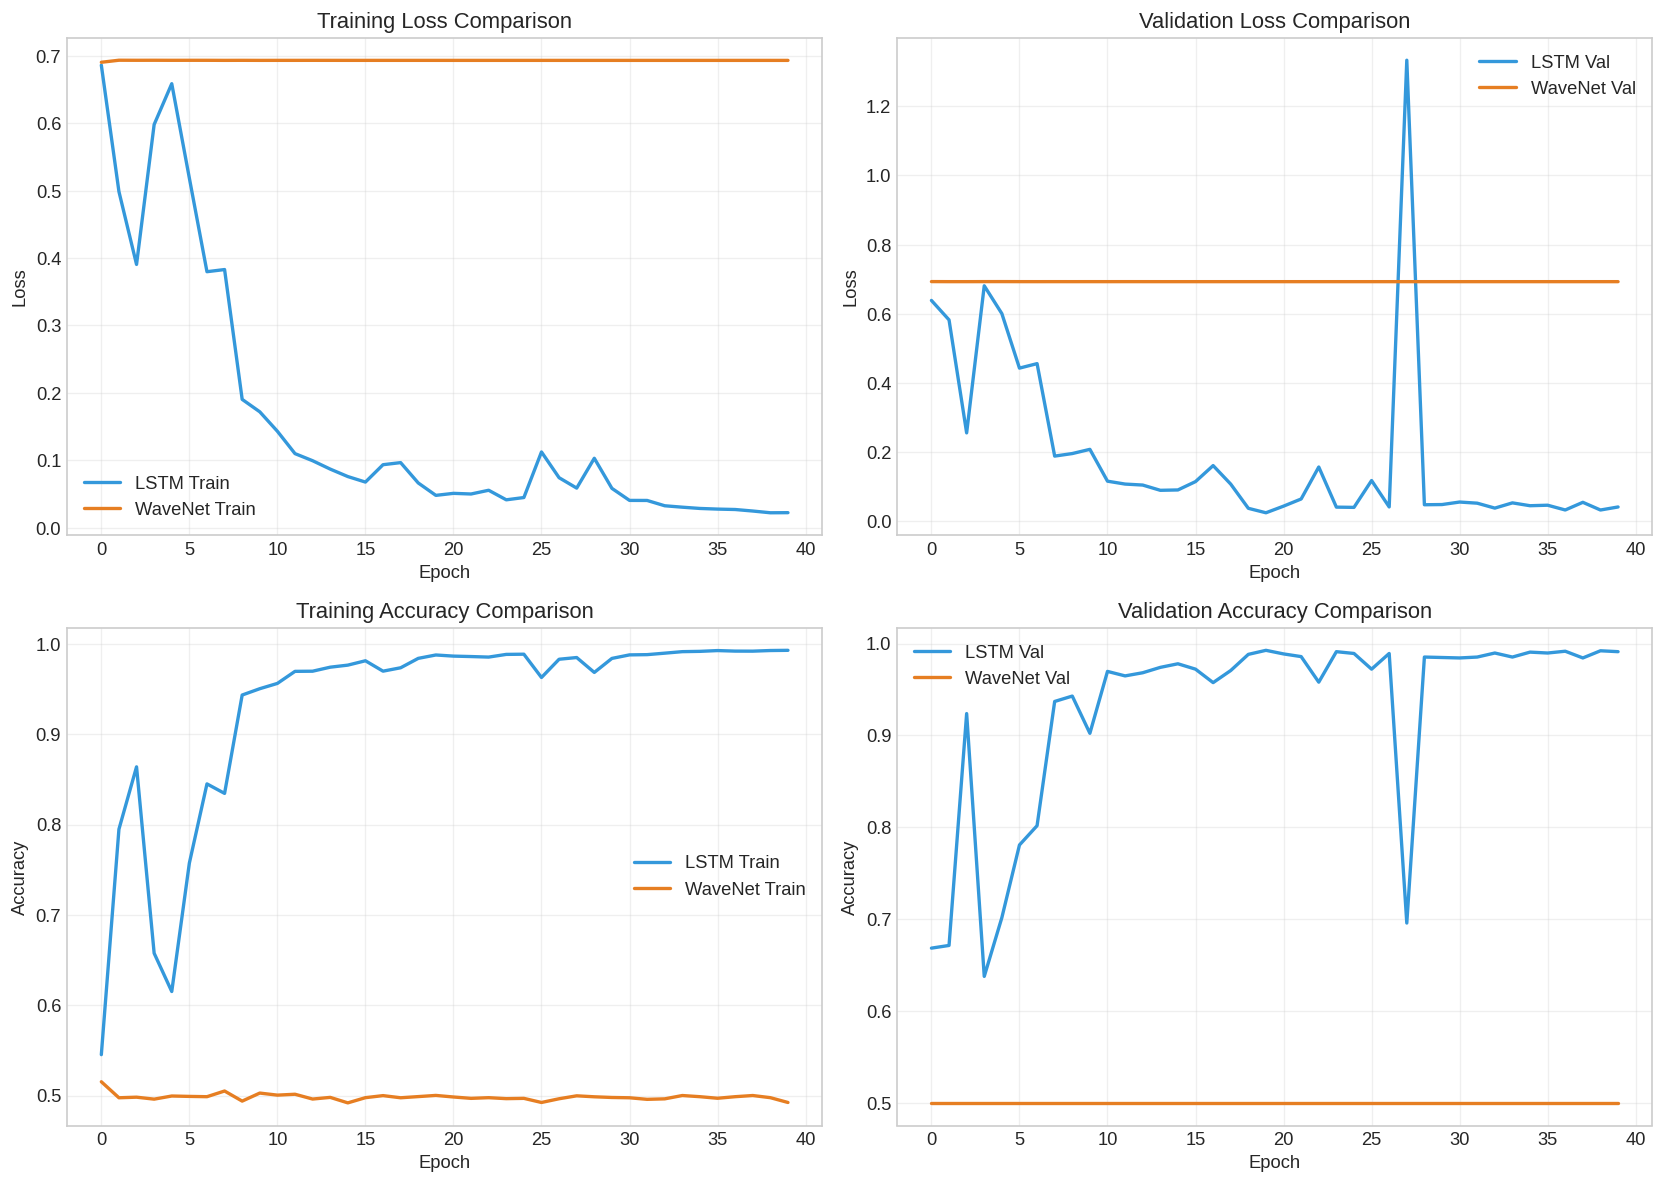

In [30]:
# --- Training curves comparison ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss comparison
axes[0, 0].plot(lstm_history['train_loss'], label='LSTM Train', linewidth=2, color='#3498db')
axes[0, 0].plot(wavenet_history['train_loss'], label='WaveNet Train', linewidth=2, color='#e67e22')
axes[0, 0].set_title('Training Loss Comparison')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(lstm_history['val_loss'], label='LSTM Val', linewidth=2, color='#3498db')
axes[0, 1].plot(wavenet_history['val_loss'], label='WaveNet Val', linewidth=2, color='#e67e22')
axes[0, 1].set_title('Validation Loss Comparison')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Accuracy comparison
axes[1, 0].plot(lstm_history['train_acc'], label='LSTM Train', linewidth=2, color='#3498db')
axes[1, 0].plot(wavenet_history['train_acc'], label='WaveNet Train', linewidth=2, color='#e67e22')
axes[1, 0].set_title('Training Accuracy Comparison')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(lstm_history['val_acc'], label='LSTM Val', linewidth=2, color='#3498db')
axes[1, 1].plot(wavenet_history['val_acc'], label='WaveNet Val', linewidth=2, color='#e67e22')
axes[1, 1].set_title('Validation Accuracy Comparison')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison.png', bbox_inches='tight')
plt.show()

---
## 10. Inference on Individual Samples

In [31]:
def predict_single_audio(filepath, lstm_model, wavenet_model, device):
    """
    Run inference on a single audio file using both models.
    Returns predictions and confidence scores.
    """
    label_map = {0: 'Real', 1: 'Fake'}

    # LSTM prediction (MFCC)
    mfcc = extract_mfcc(filepath)
    mfcc_tensor = torch.tensor(mfcc, dtype=torch.float32).unsqueeze(0).to(device)
    lstm_model.eval()
    with torch.no_grad():
        lstm_out = lstm_model(mfcc_tensor)
        lstm_probs = torch.softmax(lstm_out, dim=1).cpu().numpy()[0]
        lstm_pred = np.argmax(lstm_probs)

    # WaveNet prediction (raw audio)
    raw = extract_raw_audio(filepath)
    raw_tensor = torch.tensor(raw, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    wavenet_model.eval()
    with torch.no_grad():
        wn_out = wavenet_model(raw_tensor)
        wn_probs = torch.softmax(wn_out, dim=1).cpu().numpy()[0]
        wn_pred = np.argmax(wn_probs)

    print(f"File: {os.path.basename(filepath)}")
    print(f"  LSTM    → {label_map[lstm_pred]} (confidence: Real={lstm_probs[0]:.4f}, Fake={lstm_probs[1]:.4f})")
    print(f"  WaveNet → {label_map[wn_pred]} (confidence: Real={wn_probs[0]:.4f}, Fake={wn_probs[1]:.4f})")
    return lstm_pred, wn_pred


# --- Test on some samples from the test set ---
print("=" * 65)
print("Sample Inference Results")
print("=" * 65)

# Get file paths for test indices
df_valid = df.iloc[valid_indices].reset_index(drop=True)
test_filepaths = df_valid.iloc[test_idx]['filepath'].values
test_labels_names = df_valid.iloc[test_idx]['label_name'].values

# Show predictions for 10 random test samples
sample_indices = np.random.choice(len(test_filepaths), size=10, replace=False)
for i in sample_indices:
    print(f"\n[Ground Truth: {test_labels_names[i]}]")
    predict_single_audio(test_filepaths[i], lstm_model, wavenet_model, DEVICE)
    print("-" * 65)

Sample Inference Results

[Ground Truth: Fake]
File: 13141.wav
  LSTM    → Fake (confidence: Real=0.0021, Fake=0.9979)
  WaveNet → Real (confidence: Real=0.5099, Fake=0.4901)
-----------------------------------------------------------------

[Ground Truth: Fake]
File: 13787.wav
  LSTM    → Fake (confidence: Real=0.0014, Fake=0.9986)
  WaveNet → Real (confidence: Real=0.5099, Fake=0.4901)
-----------------------------------------------------------------

[Ground Truth: Real]
File: 10357.wav
  LSTM    → Real (confidence: Real=0.9970, Fake=0.0030)
  WaveNet → Real (confidence: Real=0.5099, Fake=0.4901)
-----------------------------------------------------------------

[Ground Truth: Fake]
File: 1773.wav
  LSTM    → Fake (confidence: Real=0.0007, Fake=0.9993)
  WaveNet → Real (confidence: Real=0.5099, Fake=0.4901)
-----------------------------------------------------------------

[Ground Truth: Fake]
File: 2093.wav
  LSTM    → Fake (confidence: Real=0.0005, Fake=0.9995)
  WaveNet → Real (c

---
## 11. Summary and Conclusion

In [32]:
print("\n" + "#" * 70)
print("#  FINAL SUMMARY")
print("#" * 70)
print(f"""
Paper Claims (on their self-made dataset of 4500 samples):
  - LSTM  accuracy: 89%
  - WaveNet accuracy: 91%
  - WaveNet outperforms LSTM

Our Results (on our dataset of {len(y_all)} samples):
  - LSTM  accuracy: {lstm_test_acc:.2%}  (Precision: {lstm_test_prec:.4f}, Recall: {lstm_test_rec:.4f}, F1: {lstm_test_f1:.4f})
  - WaveNet accuracy: {wn_test_acc:.2%}  (Precision: {wn_test_prec:.4f}, Recall: {wn_test_rec:.4f}, F1: {wn_test_f1:.4f})
  - LSTM  AUC: {roc_auc_lstm:.4f}
  - WaveNet AUC: {roc_auc_wn:.4f}

Verification of Paper Claims:
  - WaveNet outperforms LSTM: {'CONFIRMED' if wn_test_acc > lstm_test_acc else 'NOT CONFIRMED'}
  - LSTM achieves ~89% accuracy: {'SIMILAR' if abs(lstm_test_acc - 0.89) < 0.05 else 'DIFFERENT'} (ours: {lstm_test_acc:.2%})
  - WaveNet achieves ~91% accuracy: {'SIMILAR' if abs(wn_test_acc - 0.91) < 0.05 else 'DIFFERENT'} (ours: {wn_test_acc:.2%})

Note: Results may differ from the paper due to:
  - Different dataset (ours: {len(y_all)} samples from mozilla+sust; paper: 4500 self-made)
  - Different audio sources and deepfake generation methods
  - Potential differences in recording conditions and quality
""")
print("#" * 70)


######################################################################
#  FINAL SUMMARY
######################################################################

Paper Claims (on their self-made dataset of 4500 samples):
  - LSTM  accuracy: 89%
  - WaveNet accuracy: 91%
  - WaveNet outperforms LSTM

Our Results (on our dataset of 25592 samples):
  - LSTM  accuracy: 98.69%  (Precision: 0.9870, Recall: 0.9869, F1: 0.9869)
  - WaveNet accuracy: 50.00%  (Precision: 0.2500, Recall: 0.5000, F1: 0.3333)
  - LSTM  AUC: 0.9980
  - WaveNet AUC: 0.6517

Verification of Paper Claims:
  - WaveNet outperforms LSTM: NOT CONFIRMED
  - LSTM achieves ~89% accuracy: DIFFERENT (ours: 98.69%)
  - WaveNet achieves ~91% accuracy: DIFFERENT (ours: 50.00%)

Note: Results may differ from the paper due to:
  - Different dataset (ours: 25592 samples from mozilla+sust; paper: 4500 self-made)
  - Different audio sources and deepfake generation methods
  - Potential differences in recording conditions and quality

##

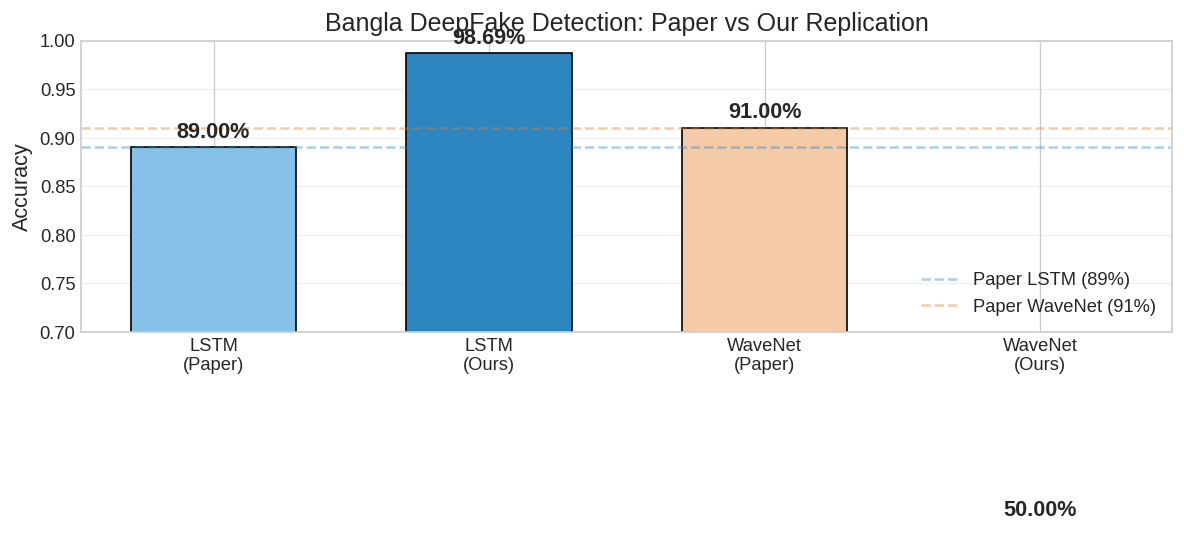


All plots saved. Notebook complete.


In [33]:
# --- Final summary visualization ---
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['LSTM\n(Paper)', 'LSTM\n(Ours)', 'WaveNet\n(Paper)', 'WaveNet\n(Ours)']
accuracies = [0.89, lstm_test_acc, 0.91, wn_test_acc]
colors = ['#85C1E9', '#2E86C1', '#F5CBA7', '#E67E22']

bars = ax.bar(categories, accuracies, color=colors, edgecolor='black', width=0.6)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Bangla DeepFake Detection: Paper vs Our Replication', fontsize=15)
ax.set_ylim(0.7, 1.0)
ax.axhline(y=0.89, color='#2E86C1', linestyle='--', alpha=0.4, label='Paper LSTM (89%)')
ax.axhline(y=0.91, color='#E67E22', linestyle='--', alpha=0.4, label='Paper WaveNet (91%)')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('final_comparison.png', bbox_inches='tight')
plt.show()

print("\nAll plots saved. Notebook complete.")